# Simulation & Stylized Facts Analysis

This notebook:

1. **Part 1: Run Simulations** — Generate synthetic order-flow databases using the Hawkes-driven simulator
2. **Part 2: Stylized Facts** — Verify that simulated markets reproduce empirical stylized facts (autocorrelation, spread dynamics, mean reversion, etc.)

In [25]:
import sqlite3
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy.stats import gaussian_kde, norm

from research_core.classes import AnalyseMarket, Simulate, helpers

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "axes.axisbelow": True})

## Part 1: Run Simulations

drift_eps=+0.100: MO_bid baseline x1.100 (MO_ask unchanged)
Loading KGHM orders for d20170110...
Replaying orders up to 2017-01-10 10:00:00+01:00...
Real BBO at snapshot: bid=98.08, ask=98.14, spread=0.06
Real book has 868 orders

Loaded 243 bids, 625 asks into simulation
order_id_counter starts at 104703
Bid depth: 77,111, Ask depth: 187,676

Pre-existing order y distribution:
  mean=0.88, median=0.90, min=0.00, max=10.94
  y < 0.5 (near execution): 155
  0.5 ≤ y ≤ 1.5 (near placement): 680
  y > 1.5 (stranded): 33

Hawkes seeded with 33,802 real events:
      MO_bid:     142 events
      MO_ask:      43 events
      LO_bid:   8,549 events
      LO_ask:   9,193 events
     CXL_bid:   8,165 events
     CXL_ask:   7,710 events

Initial intensities at t=0 (baseline → seeded):
  λ( MO_bid) = 0.013903  (baseline 0.013903,  excitation +0.000000)
  λ( MO_ask) = 0.011493  (baseline 0.011493,  excitation +0.000000)
  λ( LO_bid) = 0.000000  (baseline 0.000000,  excitation +0.000000)
  λ( LO_ask

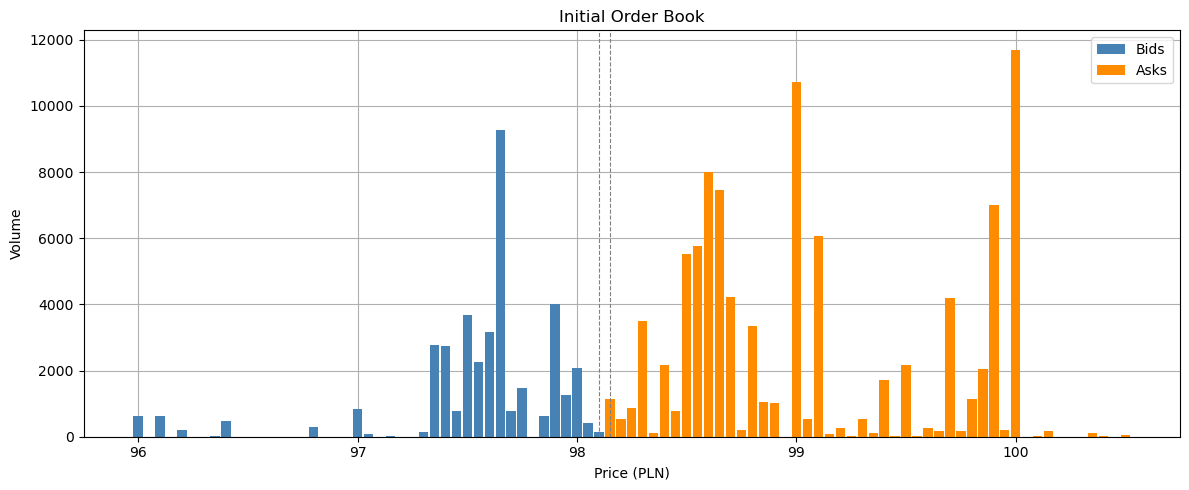

Best bid: 98.10
Best ask: 98.15
Spread: 0.05 (1 ticks)


In [35]:
# --- Single demonstration run ---
n_events = 10_000_000
asset = "KGHM"
day_key = "d20170110"
snapshot_time = "10:00:00"
tick_size = 0.05
drift_eps = 0.1

_CAL_RESIL = dict(resil_kappa=0.0817, resil_varphi=0.0746, resil_tau=4.5, resil_tau_f=32.3)
single_run_db_path = str(helpers.project_root() / "data" / "sim_events_10M.sqlite")

sim = Simulate(T=n_events, db_path=single_run_db_path, drift_eps=drift_eps, **_CAL_RESIL)
sim.load_real_orderbook_snapshot(asset=asset, day_key=day_key, snapshot_time=snapshot_time, tick_size=tick_size)
sim.plot_book()

In [27]:
sim.run(overwrite=True)


Liquidity guard: 1105 interventions (0.11% of 1000000 events)
  soft_mo_remapped: 75
  soft_cxl_remapped: 1030


In [36]:
am = AnalyseMarket(single_run_db_path, tick_size=tick_size)

AnalyseMarket | sim_events_10M.sqlite | simulation
  Tables: ['bbo', 'fills', 'intensities', 'mo_orders', 'orders']


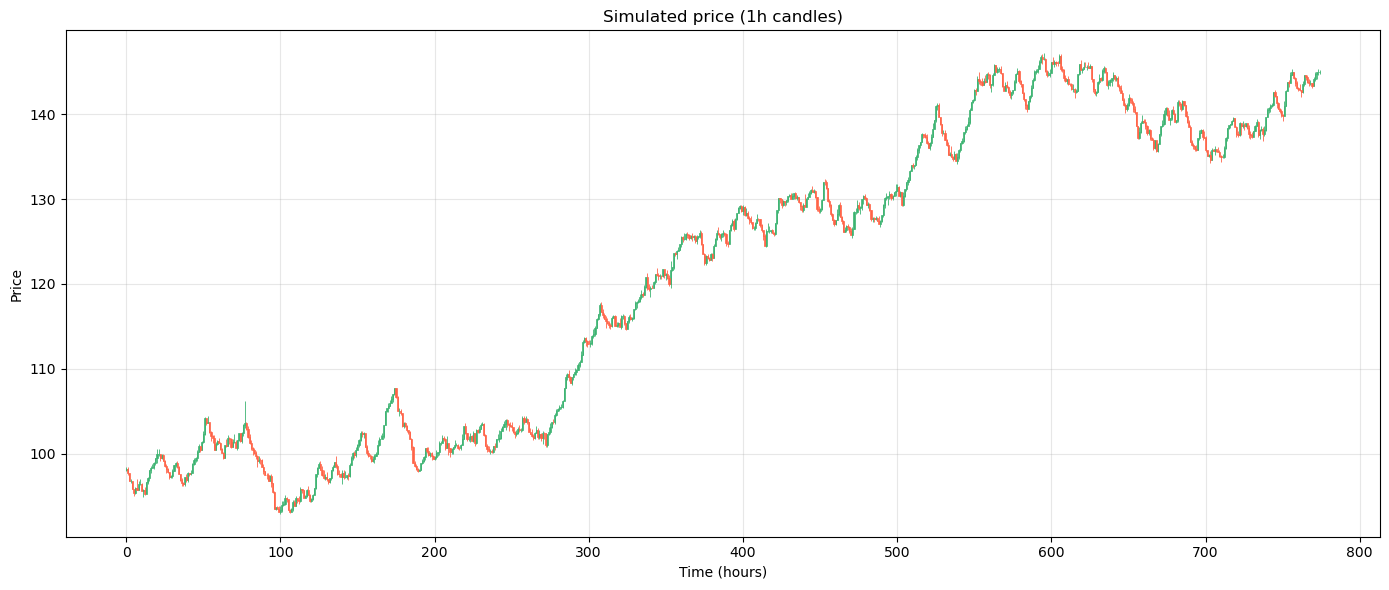

In [37]:
am.plot_candlestick(timeframe=3600, title="Simulated price (1h candles)")

Full sign series length: 303,868 MOs,  buy fraction: 0.513
Order-sign γ = 1.5639   (ρ(ℓ) ~ ℓ^{-1.5639})


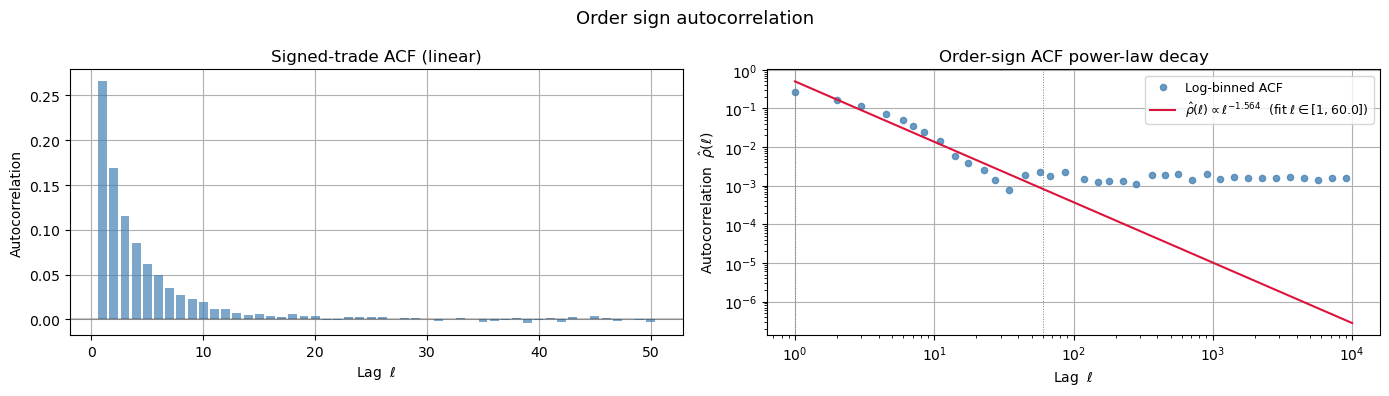

In [44]:
am.stylized_order_sign_autocorrelation(cap=60)

  99 sessions, 9,966,422 mid points, 302,846 MOs


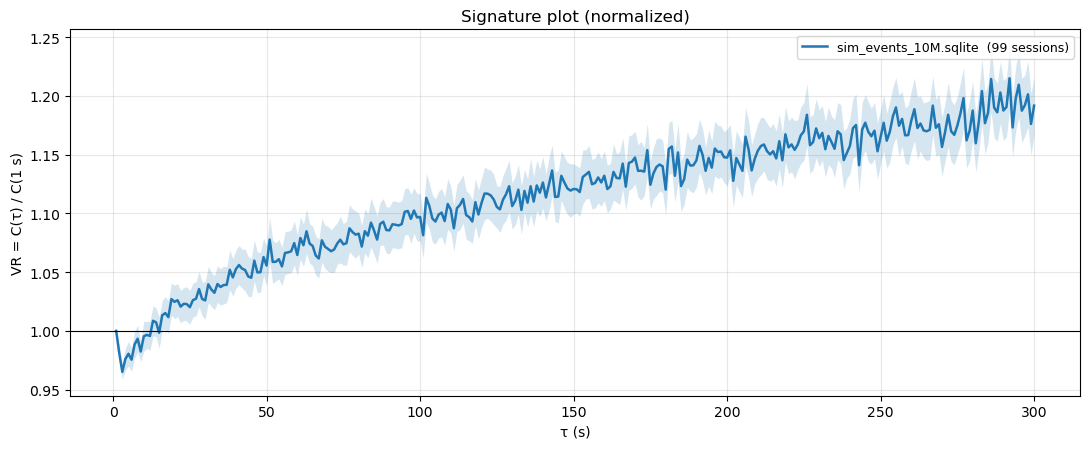

  tau      mean       SE
    3    0.9651   0.0061
    5    0.9805   0.0105
    7    0.9884   0.0115
   10    0.9954   0.0129
   20    1.0247   0.0141
   30    1.0259   0.0161
   50    1.0556   0.0172
   75    1.0736   0.0177
  100    1.0969   0.0202
  150    1.1207   0.0214
  300    1.1916   0.0245
dip min (2-15 s): 0.9651 at τ=3 s


{'taus': array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
         12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
         23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
         34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
         45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
         56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
         67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
         78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
         89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
        100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
        111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
        122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
        133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
        144., 145., 146., 147.

In [41]:
am.signature_plot()

Propagator data (303,868 MOs):
  R(1) check: 49,754 pos (16.4%), 233,745 zero (76.9%), 20,368 neg (6.7%)
  Among price-moving: 71.0% positive (expect >> 50%)
  Mean R(1): 0.004751


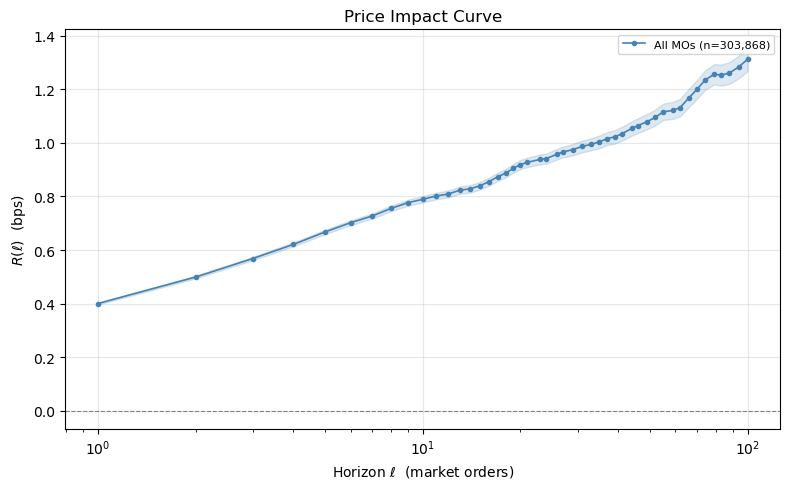

MOs total: 303,868
  walked ticks:    43,812
  no tick walk:    260,056
  R(1)  = +0.400 bps
  R(100) = +1.311 bps


In [42]:
am.price_impact_propagator()

## Batch Simulation Runs

Generate N independent simulation databases for downstream use by the RL pipeline notebook.

In [ ]:
# --- Batch simulation databases for the stylized-facts panels ---
n_events = 1_000_000
tick_size = 0.05
n_runs = 60
max_workers = 12
batch_data_dir = helpers.project_root() / "data"

resiliency_kwargs = dict(resil_kappa=0.0817, resil_varphi=0.0746, resil_tau=4.5, resil_tau_f=32.3)


def run_simulation(run_id: int, db_path: str) -> int:
    simulation = Simulate(T=n_events, db_path=db_path, recording_mode="full", drift_eps=drift_eps, **resiliency_kwargs)
    simulation.load_real_orderbook_snapshot(asset=asset, day_key=day_key, snapshot_time=snapshot_time, tick_size=tick_size)
    simulation.run()
    return run_id


missing_runs = [run_id for run_id in range(n_runs) if not (batch_data_dir / f"sim_events_1M_{run_id}.sqlite").exists()]

if missing_runs:
    batch_start_time = time.time()
    completed_runs = Parallel(n_jobs=max_workers, verbose=10)(
        delayed(run_simulation)(run_id, str(batch_data_dir / f"sim_events_1M_{run_id}.sqlite")) for run_id in missing_runs
    )
    print(f"Simulated {len(completed_runs)} missing runs in {time.time() - batch_start_time:.0f}s")
else:
    print(f"Simulation databases already exist: {n_runs} runs")

Simulation databases already exist: 60 runs


## Part 2: Stylized Facts Analysis

In [17]:
# --- One run for quick interactive plots ---
tick_size = 0.05
plot_run = 0
data_dir = helpers.project_root() / "data"
plot_db_path = data_dir / f"sim_events_1M_{plot_run}.sqlite"

market_analysis = AnalyseMarket(str(plot_db_path), tick_size=tick_size)
print(f"Loaded: {plot_db_path.name}")

AnalyseMarket | sim_events_1M_0.sqlite | simulation
  Tables: ['bbo', 'fills', 'intensities', 'mo_orders', 'orders']
Loaded: sim_events_1M_0.sqlite


Stylized facts: 30 simulation runs
BBO facts processed: 30 runs


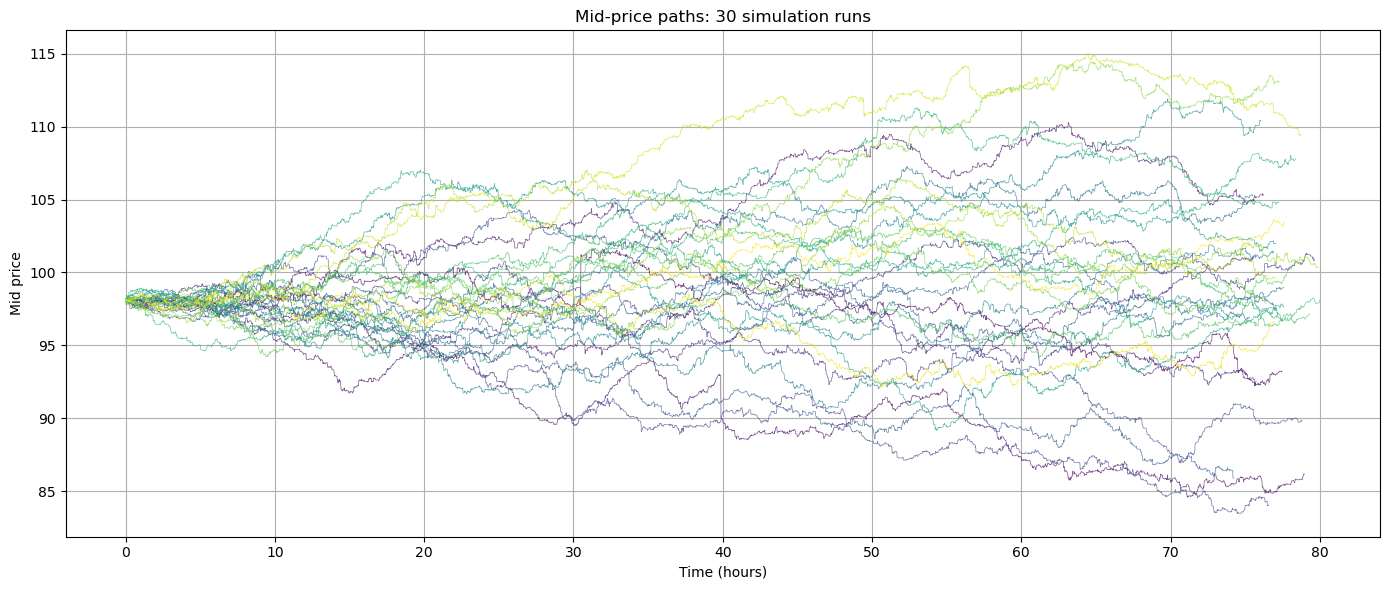

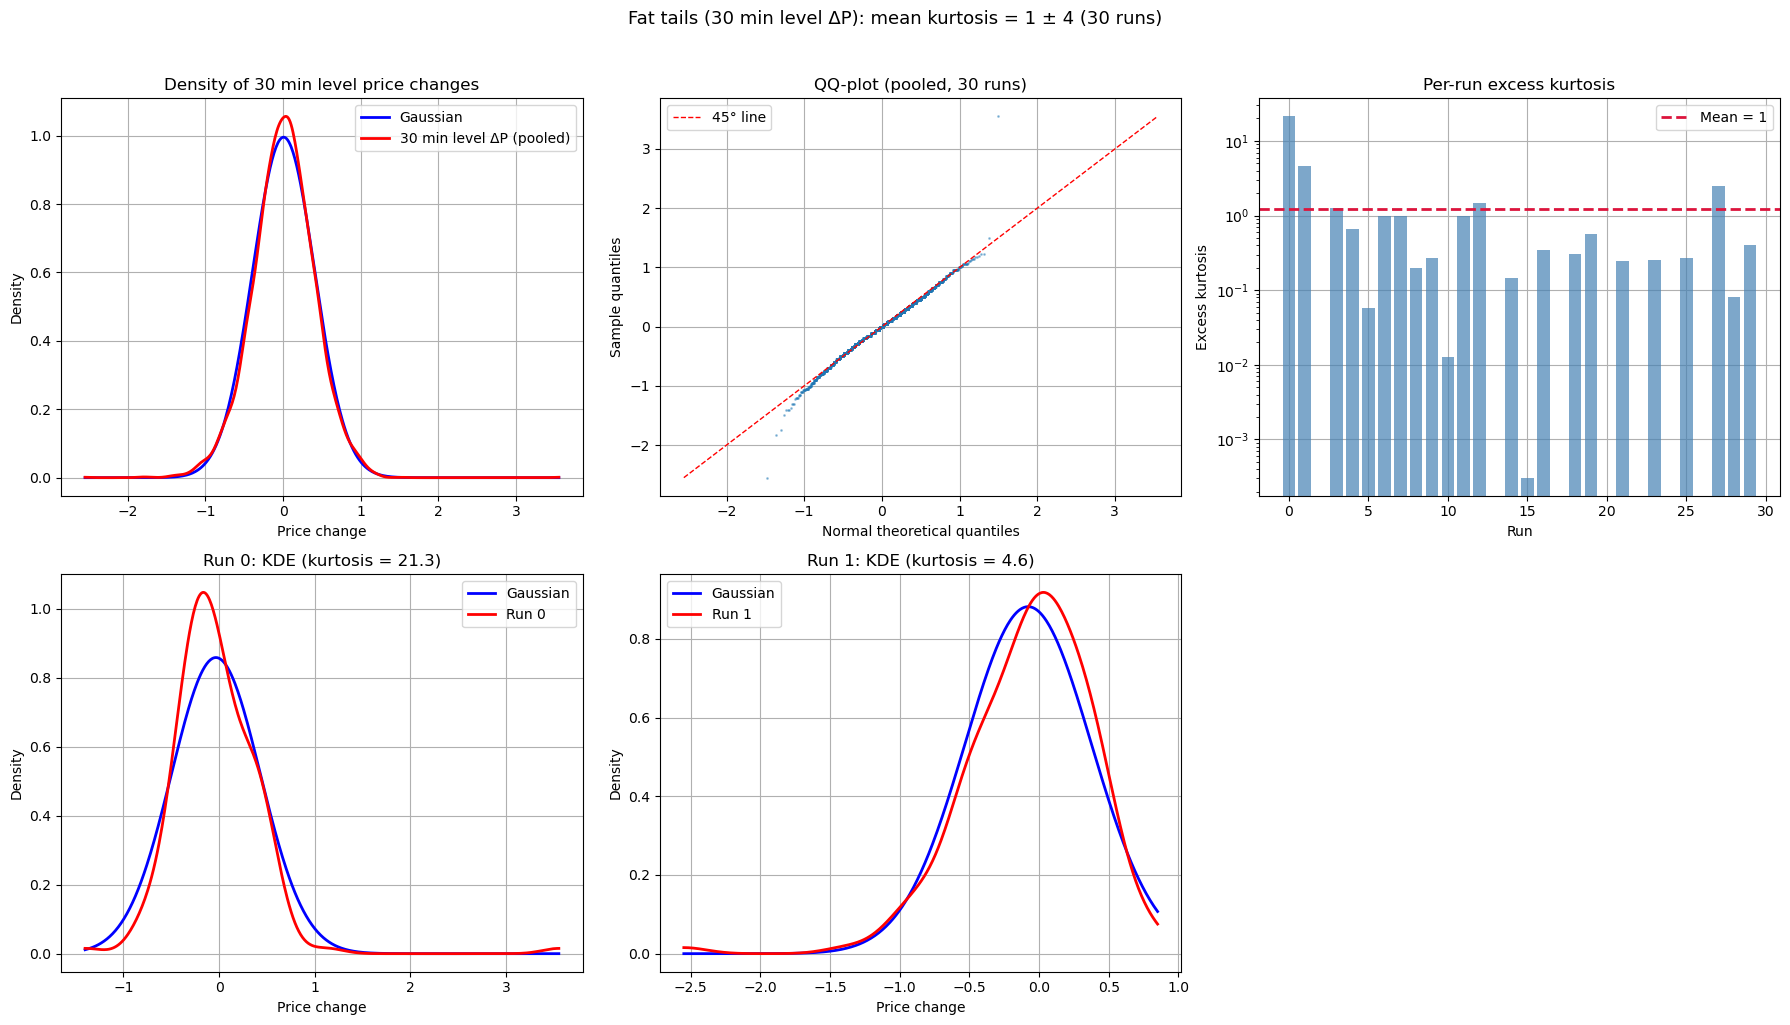

Per-run excess kurtosis: 1 ± 4 (min=-1, max=21)


In [ ]:
# --- Stylized-facts config ---
analysis_n_runs = 30
resample_dt_s = 60.0
resample_label = f"{resample_dt_s / 60:.0f}min"
max_lag_returns = 50
max_lag_volatility = 100
aggregation_minutes = [1, 5, 15, 30, 60, 120]
fat_tail_minutes = 30
individual_runs = [0, 1]

db_paths = [data_dir / f"sim_events_1M_{run_id}.sqlite" for run_id in range(analysis_n_runs)]
print(f"Stylized facts: {analysis_n_runs} simulation runs")


def sample_mids_locf(timestamps: np.ndarray, mids: np.ndarray, interval_s: float) -> np.ndarray:
    grid = np.arange(timestamps[0], timestamps[-1], interval_s)
    grid_indices = np.clip(np.searchsorted(timestamps, grid, side="right") - 1, 0, len(mids) - 1)
    return mids[grid_indices]


bbo = {
    "ft_kurtoses": [], "ft_changes": [],
    "acf_ret": [], "n_rets": [],
    "acf_abs": [], "acf_sq": [], "half_lives": [],
    "agg_kurtoses": [],
}

# --- BBO extraction: one SQLite pass per run ---
for run_id, db_path in enumerate(db_paths):
    market_run = AnalyseMarket(db_path, tick_size=tick_size, verbose=False)
    timestamps, mids = market_run._get_mid_prices()
    timestamps = np.asarray(timestamps, dtype=np.float64)
    mids = np.asarray(mids, dtype=np.float64)

    mids_resampled = sample_mids_locf(timestamps, mids, resample_dt_s)

    log_mids = np.log(mids_resampled)
    returns = np.diff(log_mids)
    n_returns = len(returns)
    bbo["n_rets"].append(n_returns)

    # Fat tails use level price changes at the same 30-minute horizon as the empirical notebook.
    fat_tail_mids = sample_mids_locf(timestamps, mids, fat_tail_minutes * 60.0)
    fat_tail_changes = np.diff(fat_tail_mids)
    fat_tail_mean = fat_tail_changes.mean()
    fat_tail_std = fat_tail_changes.std()
    bbo["ft_kurtoses"].append(np.mean(((fat_tail_changes - fat_tail_mean) / fat_tail_std) ** 4) - 3.0)
    bbo["ft_changes"].append(fat_tail_changes)

    demeaned_returns = returns - returns.mean()
    return_variance = np.dot(demeaned_returns, demeaned_returns)
    return_lags = np.arange(1, min(max_lag_returns + 1, n_returns))
    return_acf = np.array([np.dot(demeaned_returns[lag:], demeaned_returns[:-lag]) / return_variance for lag in return_lags])
    bbo["acf_ret"].append(return_acf)

    abs_return_acf = AnalyseMarket._acf(np.abs(returns), max_lag_volatility)
    squared_return_acf = AnalyseMarket._acf(returns ** 2, max_lag_volatility)
    bbo["acf_abs"].append(abs_return_acf)
    bbo["acf_sq"].append(squared_return_acf)

    half_life_threshold = abs_return_acf[0] / np.e
    half_life_candidates = np.where(abs_return_acf < half_life_threshold)[0]
    if len(half_life_candidates):
        bbo["half_lives"].append(half_life_candidates[0] + 1)
    else:
        bbo["half_lives"].append(max_lag_volatility)

    aggregation_kurtoses = []
    individual_aggregation_returns = {}
    for horizon_minutes in aggregation_minutes:
        sampled_mids = sample_mids_locf(timestamps, mids, horizon_minutes * 60.0)
        horizon_returns = np.diff(sampled_mids)
        horizon_kurtosis = np.mean(((horizon_returns - horizon_returns.mean()) / horizon_returns.std()) ** 4) - 3.0
        aggregation_kurtoses.append(horizon_kurtosis)

        if run_id in individual_runs:
            individual_aggregation_returns[horizon_minutes] = horizon_returns.copy()

    bbo["agg_kurtoses"].append(aggregation_kurtoses)
    if run_id in individual_runs:
        bbo.setdefault("agg_level_returns_individual", {})[run_id] = individual_aggregation_returns

# Convert lists to arrays once all runs have been processed.
bbo["n_rets"] = np.array(bbo["n_rets"])
bbo["ft_kurtoses"] = np.array(bbo["ft_kurtoses"])
bbo["ft_pooled"] = np.concatenate(bbo["ft_changes"])
bbo["ft_changes_individual"] = {run_id: bbo["ft_changes"][run_id] for run_id in individual_runs}
del bbo["ft_changes"]
bbo["acf_ret"] = np.array(bbo["acf_ret"])
bbo["acf_abs"] = np.array(bbo["acf_abs"])
bbo["acf_sq"] = np.array(bbo["acf_sq"])
bbo["half_lives"] = np.array(bbo["half_lives"])
bbo["agg_kurtoses"] = np.array(bbo["agg_kurtoses"])

print(f"BBO facts processed: {len(bbo['ft_kurtoses'])} runs")

# --- Mid-price paths across simulation runs ---
mid_series = {}
for run_id, db_path in enumerate(db_paths):
    with sqlite3.connect(db_path) as connection:
        mid_frame = pd.read_sql("SELECT timestamp, mid_price FROM bbo ORDER BY timestamp", connection)

    timestamps = mid_frame["timestamp"].to_numpy(dtype=float)
    mids = mid_frame["mid_price"].to_numpy(dtype=float)
    time_grid = np.arange(timestamps[0], timestamps[-1], resample_dt_s)
    grid_indices = np.clip(np.searchsorted(timestamps, time_grid, side="right") - 1, 0, len(mids) - 1)
    elapsed_minutes = (time_grid - timestamps[0]) / 60.0
    mid_series[run_id] = (elapsed_minutes, mids[grid_indices])

fig, ax = plt.subplots(figsize=(14, 6))
color_map = plt.cm.viridis(np.linspace(0, 1, analysis_n_runs))
for run_id, (elapsed_minutes, mids) in mid_series.items():
    ax.plot(elapsed_minutes / 60, mids, lw=0.5, alpha=0.7, color=color_map[run_id])
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Mid price")
ax.set_title(f"Mid-price paths: {len(mid_series)} simulation runs")
plt.tight_layout()
plt.show()


AnalyseMarket | sim_events_1M_0.sqlite | simulation
  Tables: ['bbo', 'fills', 'intensities', 'mo_orders', 'orders']


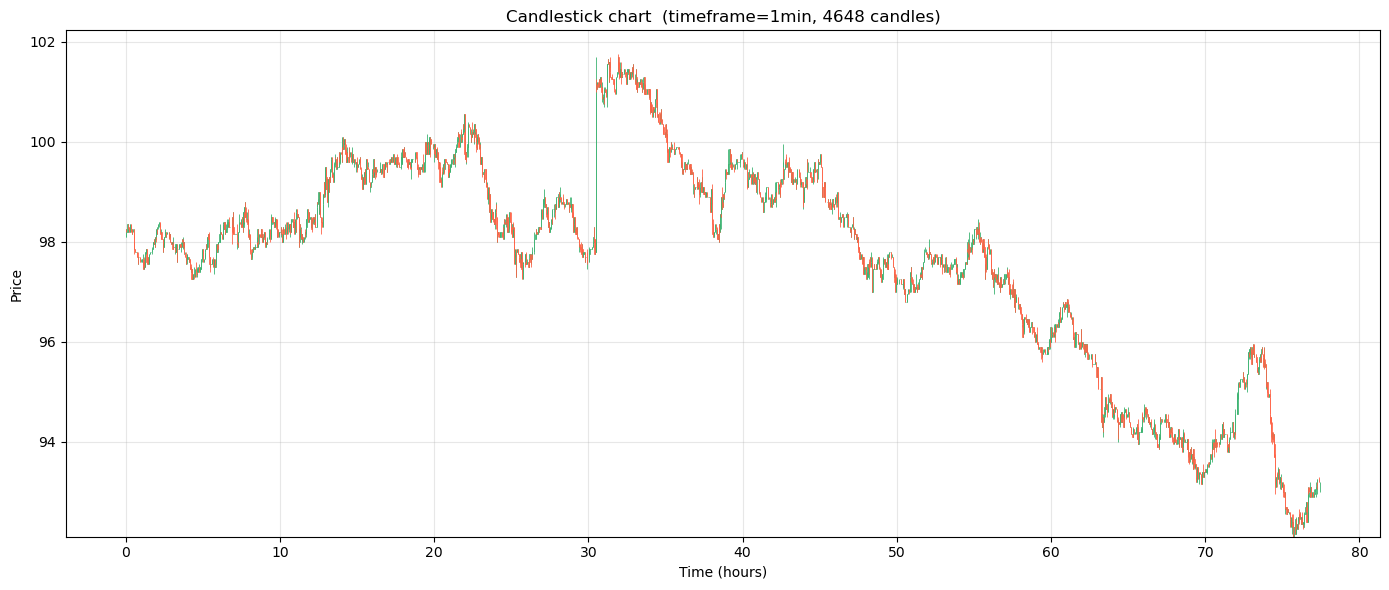

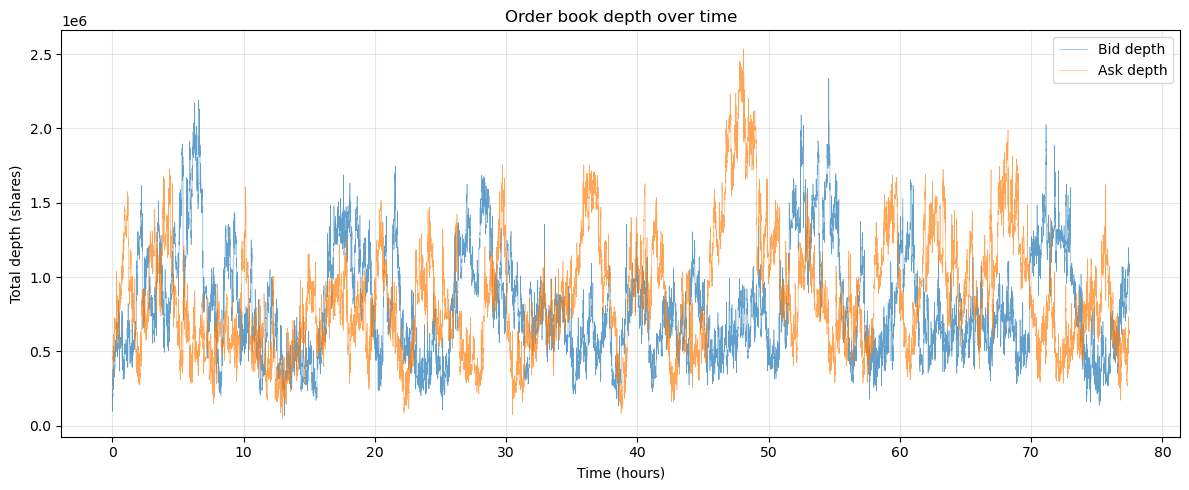

In [20]:
# --- Quick single-run market plots ---
single_run_analysis = AnalyseMarket(str(data_dir / "sim_events_1M_0.sqlite"), tick_size=tick_size)
single_run_analysis.plot_candlestick(timeframe=60)
single_run_analysis.plot_depth(n_events=1_000_000, offset=0)